In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [143]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

## Data Cleaning

In [106]:
df = pd.read_csv("D:\\My Courses\\ML Course\\DataSets\\HousePrices.csv")
df.head(20)

,Id,LotArea,TotalRooms,YearBuilt,GarageCars,PropertyType,CentralAir,Neighborhood,DistanceToCenter,SalePrice
0,1,1000000.000000,6,2019.0,0,Studio,Yes,Rural,22.719419,283723.061121
1,2,NaN,3,1994.0,0,Villa,No,Suburbs,10.126002,50.000000
2,3,NaN,99,1996.0,0,Apartment,No,Rural,24.781900,290302.848318
3,4,7284.544785,9,2050.0,3,Apartment,Yes,Downtown,41.678685,331503.654790
4,5,4648.769938,3,1963.0,3,Duplex,Yes,Suburbs,47.579977,185141.494715
5,6,4648.794565,2,2003.0,2,Apartment,Yes,Downtown,32.078380,177822.642690
6,7,7368.819223,7,2020.0,2,Apartment,Yes,Suburbs,18.341378,346152.350452
7,8,6151.152094,7,1995.0,2,Villa,Y,Downtown,30.562953,297926.032185
8,9,4295.788421,4,NaN,0,Apartment,Yes,Rural,16.288064,204036.396805
9,10,5813.840065,9,2008.0,1,Villa,Yes,Suburbs,45.581358,313745.441311


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2825 entries, 0 to 2824
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2825 non-null   int64  
 1   LotArea           2401 non-null   float64
 2   TotalRooms        2825 non-null   int64  
 3   YearBuilt         2543 non-null   float64
 4   GarageCars        2825 non-null   int64  
 5   PropertyType      2825 non-null   object 
 6   CentralAir        2825 non-null   object 
 7   Neighborhood      2825 non-null   object 
 8   DistanceToCenter  2825 non-null   float64
 9   SalePrice         2825 non-null   float64
dtypes: float64(4), int64(3), object(3)
memory usage: 220.8+ KB


In [108]:
df.shape

(2825, 10)

In [109]:
df.isnull().sum()

Id                    0
LotArea             424
TotalRooms            0
YearBuilt           282
GarageCars            0
PropertyType          0
CentralAir            0
Neighborhood          0
DistanceToCenter      0
SalePrice             0
dtype: int64

In [110]:
df.describe()

,Id,LotArea,TotalRooms,YearBuilt,GarageCars,DistanceToCenter,SalePrice
count,2825.00000,2401.000000,2825.000000,2543.000000,2825.000000,2825.000000,2825.000000
mean,1413.00000,5458.017294,5.021239,1987.023594,1.511504,25.694777,233857.315336
std,815.65158,20358.972756,3.115728,21.461606,1.130299,14.200264,54968.869367
min,1.00000,138.098990,1.000000,1950.000000,0.000000,1.007729,50.000000
25%,707.00000,4032.320368,3.000000,1968.000000,1.000000,13.357563,194330.200376
50%,1413.00000,5036.329185,5.000000,1987.000000,1.000000,25.547496,234325.751853
75%,2119.00000,6012.229238,7.000000,2006.000000,3.000000,38.218530,273423.899915
max,2825.00000,1000000.000000,99.000000,2050.000000,3.000000,49.983987,426682.615119


In [112]:
df['CentralAir'] = df['CentralAir'].str.lower().replace('y', 'yes')
df['CentralAir'].unique()

array(['yes', 'no'], dtype=object)

In [113]:
df['LotArea'] = df['LotArea'].fillna(df['LotArea'].mean())
df['LotArea'].isnull().sum()

0

In [114]:
df['YearBuilt'] = df['YearBuilt'].fillna(df['YearBuilt'].median())
df['YearBuilt'].isnull().sum()

0

In [115]:
df.loc[df['YearBuilt'] > 2025, 'YearBuilt'] = 2025
df['YearBuilt'].max()

2025.0

In [122]:
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df["SalePrice"] >= lower_limit) & (df["SalePrice"] <= upper_limit)]
df.head(20)

,Id,LotArea,TotalRooms,YearBuilt,GarageCars,PropertyType,CentralAir,Neighborhood,DistanceToCenter,SalePrice
0,1,1000000.000000,6,2019.0,0,Studio,yes,Rural,22.719419,283723.061121
2,3,5458.017294,99,1996.0,0,Apartment,no,Rural,24.781900,290302.848318
3,4,7284.544785,9,2025.0,3,Apartment,yes,Downtown,41.678685,331503.654790
4,5,4648.769938,3,1963.0,3,Duplex,yes,Suburbs,47.579977,185141.494715
5,6,4648.794565,2,2003.0,2,Apartment,yes,Downtown,32.078380,177822.642690
6,7,7368.819223,7,2020.0,2,Apartment,yes,Suburbs,18.341378,346152.350452
7,8,6151.152094,7,1995.0,2,Villa,yes,Downtown,30.562953,297926.032185
8,9,4295.788421,4,1987.0,0,Apartment,yes,Rural,16.288064,204036.396805
9,10,5813.840065,9,2008.0,1,Villa,yes,Suburbs,45.581358,313745.441311
10,11,4304.873461,8,1978.0,3,Duplex,yes,Rural,43.649623,250865.477188


In [124]:
Q1 = df["LotArea"].quantile(0.25)
Q3 = df["LotArea"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df["LotArea"] >= lower_limit) & (df["LotArea"] <= upper_limit)]
df.head(20)

,Id,LotArea,TotalRooms,YearBuilt,GarageCars,PropertyType,CentralAir,Neighborhood,DistanceToCenter,SalePrice
2,3,5458.017294,99,1996.0,0,Apartment,no,Rural,24.781900,290302.848318
3,4,7284.544785,9,2025.0,3,Apartment,yes,Downtown,41.678685,331503.654790
4,5,4648.769938,3,1963.0,3,Duplex,yes,Suburbs,47.579977,185141.494715
5,6,4648.794565,2,2003.0,2,Apartment,yes,Downtown,32.078380,177822.642690
6,7,7368.819223,7,2020.0,2,Apartment,yes,Suburbs,18.341378,346152.350452
7,8,6151.152094,7,1995.0,2,Villa,yes,Downtown,30.562953,297926.032185
8,9,4295.788421,4,1987.0,0,Apartment,yes,Rural,16.288064,204036.396805
9,10,5813.840065,9,2008.0,1,Villa,yes,Suburbs,45.581358,313745.441311
10,11,4304.873461,8,1978.0,3,Duplex,yes,Rural,43.649623,250865.477188
11,12,4301.405370,1,1966.0,0,Villa,no,Rural,28.353356,128808.272252


In [133]:
Q1 = df["TotalRooms"].quantile(0.25)
Q3 = df["TotalRooms"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df["TotalRooms"] >= lower_limit) & (df["TotalRooms"] <= upper_limit)]
df.describe()

,Id,LotArea,TotalRooms,YearBuilt,GarageCars,CentralAir,DistanceToCenter,SalePrice
count,2756.000000,2756.000000,2756.000000,2756.000000,2756.000000,2756.000000,2756.000000,2756.000000
mean,1413.096880,5111.994896,4.986938,1986.880624,1.513062,0.818578,25.690071,233905.483394
std,816.218749,1255.322865,2.568660,20.307346,1.130429,0.385438,14.187587,53754.934153
min,4.000000,1817.217651,1.000000,1950.000000,0.000000,0.000000,1.007729,78734.369984
25%,705.750000,4260.452890,3.000000,1970.000000,0.750000,1.000000,13.383619,194799.909886
50%,1413.500000,5377.743566,5.000000,1987.000000,1.000000,1.000000,25.557962,234385.673698
75%,2122.250000,5820.733304,7.000000,2004.000000,3.000000,1.000000,38.194460,272726.099449
max,2825.000000,8256.414076,9.000000,2025.000000,3.000000,1.000000,49.983987,391644.678998


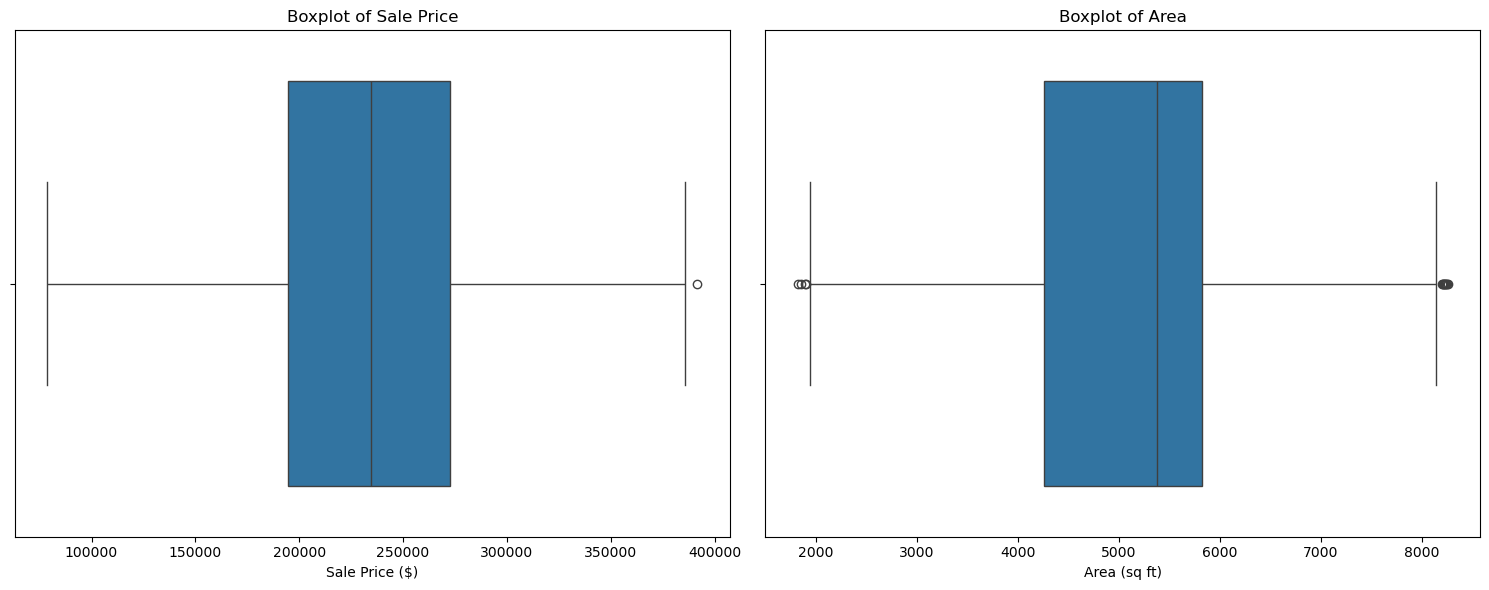

In [134]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['SalePrice'])
plt.title('Boxplot of Sale Price')
plt.xlabel('Sale Price ($)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['LotArea'])
plt.title('Boxplot of Area')
plt.xlabel('Area (sq ft)')

plt.tight_layout()
plt.show()

## Data Preprocessing

In [135]:
df['CentralAir'] = df['CentralAir'].astype(str).str.strip().str.lower()
df['CentralAir'] = df['CentralAir'].replace({'yes': 1, 'no': 0})

print(df['CentralAir'].value_counts())

CentralAir
1    2256
0     500
Name: count, dtype: int64


In [156]:
df = pd.get_dummies(df, columns=['PropertyType', 'Neighborhood'], drop_first=True)
df.head(10)

KeyError: "None of [Index(['PropertyType', 'Neighborhood'], dtype='object')] are in the [columns]"

## Data Visualization

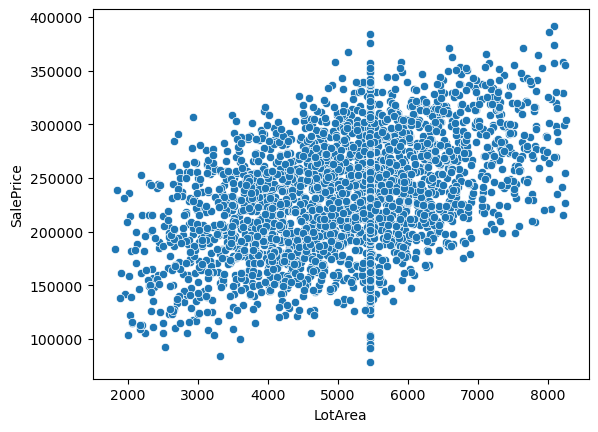

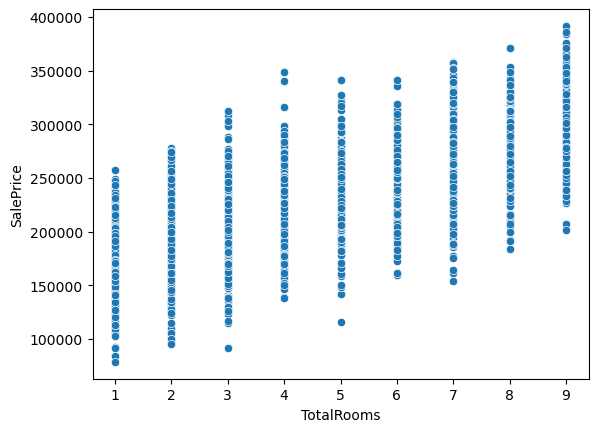

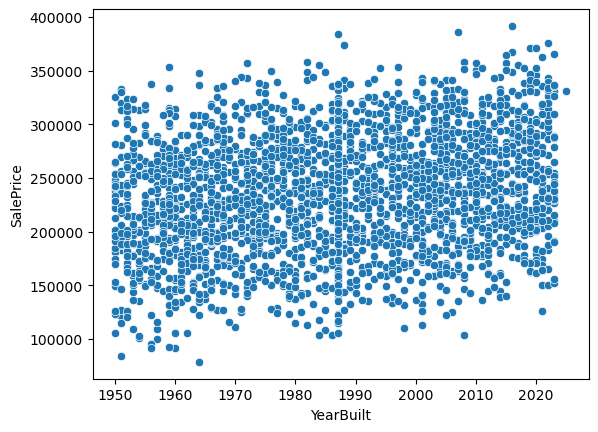

In [137]:
important_features = ['LotArea', 'TotalRooms', 'YearBuilt']
for feature in important_features:
    sns.scatterplot(data = df, x = df[feature], y = df['SalePrice'])
    plt.show()

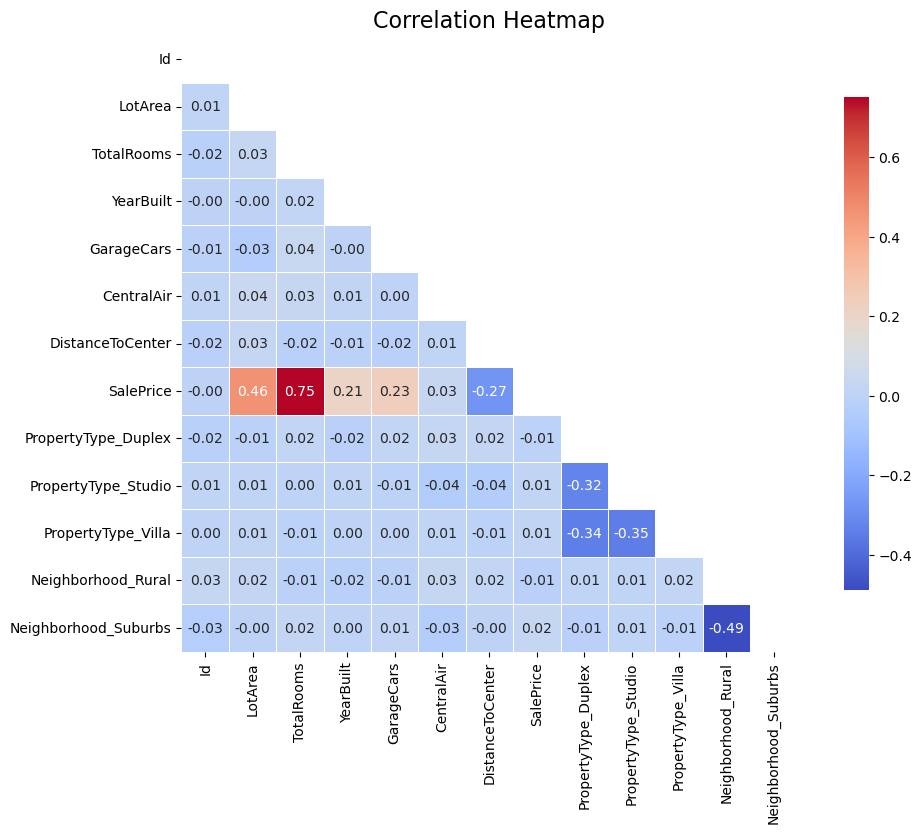

In [138]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

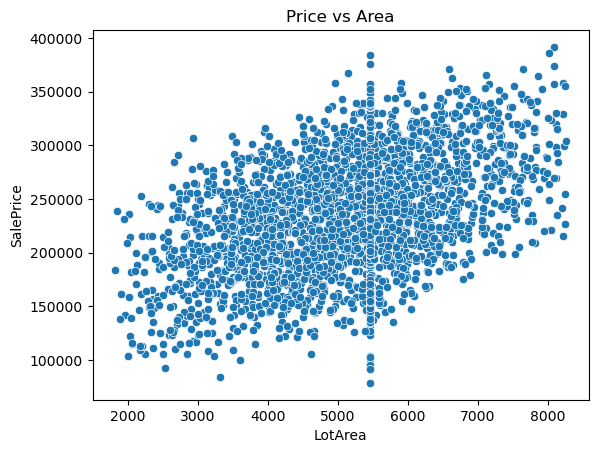

In [132]:
sns.scatterplot(df, x = "LotArea", y = "SalePrice")

plt.title("Price vs Area")
plt.show()

## Regression 

In [145]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

R2 Score: 0.9124


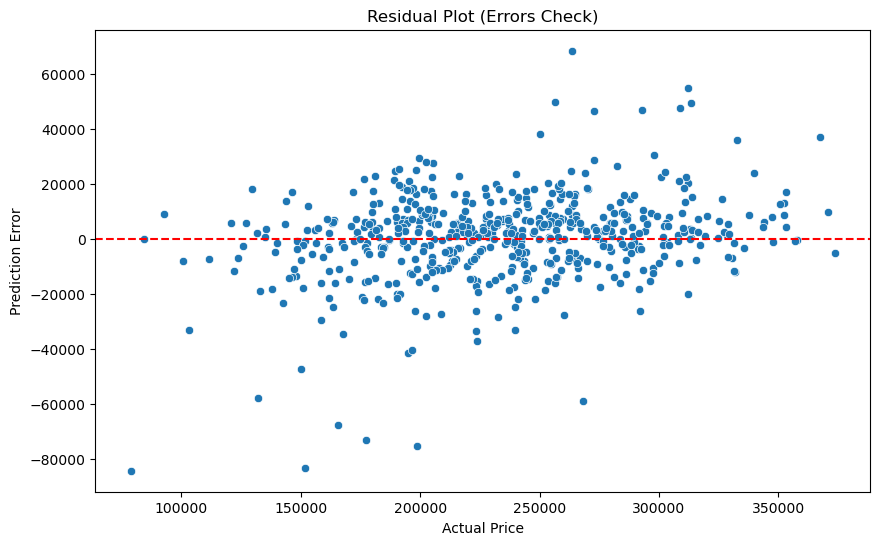

In [146]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=(y_test - y_pred))
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot (Errors Check)")
plt.xlabel("Actual Price")
plt.ylabel("Prediction Error")
plt.show()

In [147]:
def predict_house_price(area, rooms, year, garage, distance, p_type, neighborhood, air):
    house_data = {
        'LotArea': [area],
        'TotalRooms': [rooms],
        'YearBuilt': [year],
        'GarageCars': [garage],
        'DistanceToCenter': [distance],
        'CentralAir': [1 if air.lower() == 'yes' else 0]
    }
    
    for col in X.columns:
        if col not in house_data:
            house_data[col] = [0]
            
    test_df = pd.DataFrame(house_data)
    
    if f'PropertyType_{p_type}' in test_df.columns:
        test_df[f'PropertyType_{p_type}'] = 1
    if f'Neighborhood_{neighborhood}' in test_df.columns:
        test_df[f'Neighborhood_{neighborhood}'] = 1
        
    test_df = test_df[X.columns]
    
    prediction = model.predict(test_df)
    return prediction[0]

In [155]:
house = predict_house_price(
    area=6000, 
    rooms=3, 
    year=2010, 
    garage=2, 
    distance=5, 
    p_type='Villa', 
    neighborhood='Downtown', 
    air='yes'
)

print(f"Predicted Price: ${house:,.2f}")

Predicted Price: $258,044.84
